NICE! Episode: 585, Timestep: 31, Reward: 29.92561692646874
NICE! Episode: 585, Timestep: 32, Reward: 29.913922904175635
NICE! Episode: 585, Timestep: 33, Reward: 29.90729039279005
NICE! Episode: 585, Timestep: 34, Reward: 29.91210977212298
NICE! Episode: 585, Timestep: 35, Reward: 29.902539505909726
NICE! Episode: 585, Timestep: 36, Reward: 29.91002274485624
NICE! Episode: 585, Timestep: 37, Reward: 29.90151182410371
NICE! Episode: 585, Timestep: 38, Reward: 29.910532227965337
NICE! Episode: 585, Timestep: 39, Reward: 29.885031099586122
NICE! Episode: 585, Timestep: 40, Reward: 29.912622111219644
NICE! Episode: 585, Timestep: 41, Reward: 29.905215825399843
NICE! Episode: 585, Timestep: 42, Reward: 29.896151946318625
NICE! Episode: 585, Timestep: 43, Reward: 29.893553416499064
NICE! Episode: 585, Timestep: 44, Reward: 29.919270547893692
NICE! Episode: 585, Timestep: 45, Reward: 29.880547229619598
NICE! Episode: 585, Timestep: 46, Reward: 29.91765699181589
NICE! Episode: 585, Timestep: 

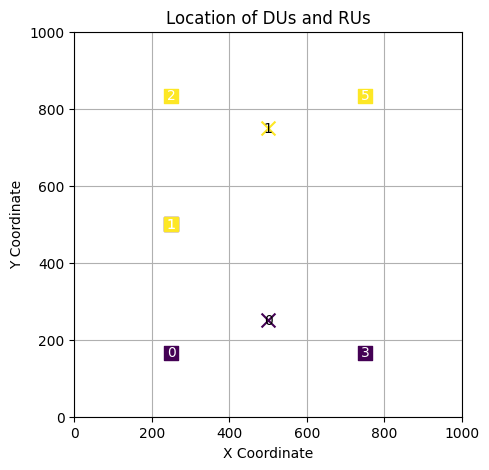

-------------
Runtime Duration:
-------------



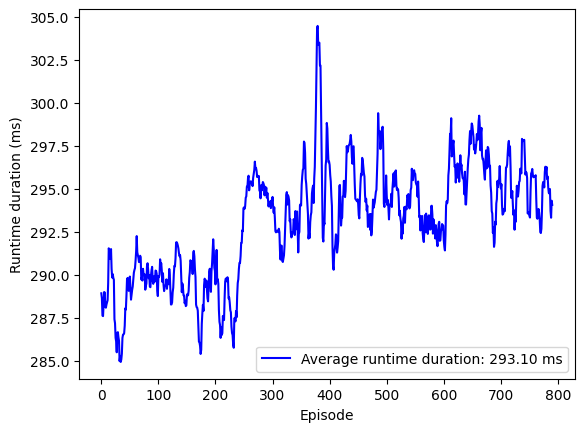

-------------
Avg PRBs used per user for SAC algorithm:
-------------



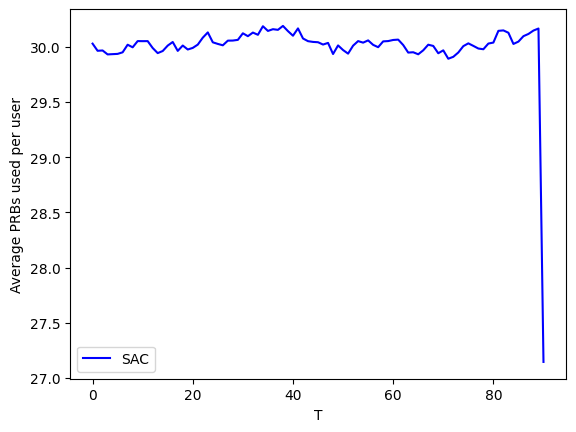

IndexError: index 200 is out of bounds for axis 0 with size 200

In [1]:
%run "main_constraint-based.py"

-------------
logarithmic rewards:
-------------



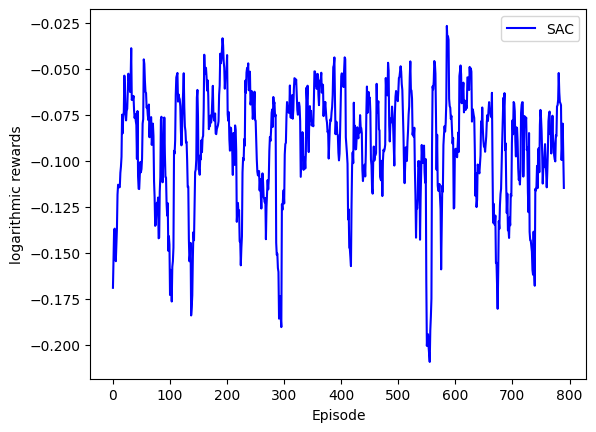

-------------
Mean episodic rewards:
-------------



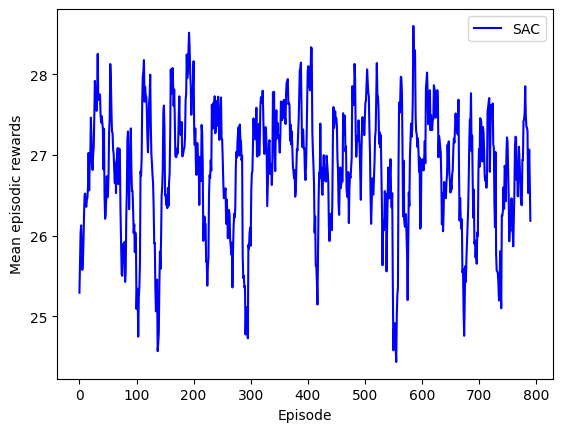

-------------
Constraint Satisfaction:
-------------



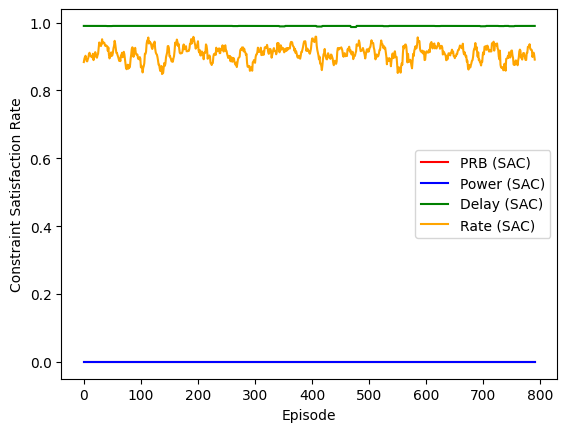

-------------
SSL Metrics:
-------------



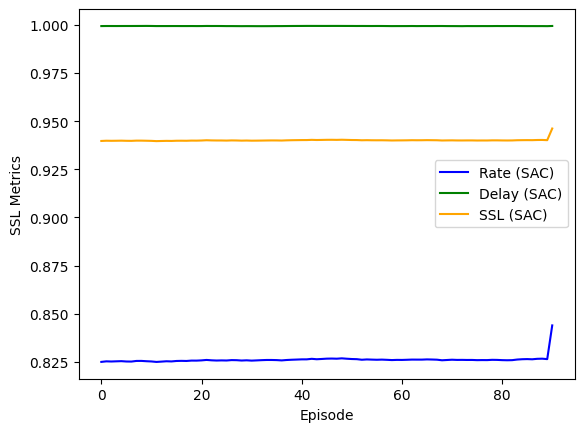

-------------
Comparison of Average E2E Delay (SAC):
-------------



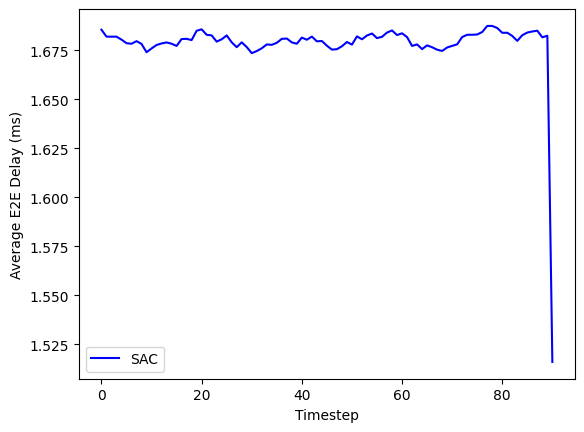

-------------
Average Data Rate (SAC):
-------------



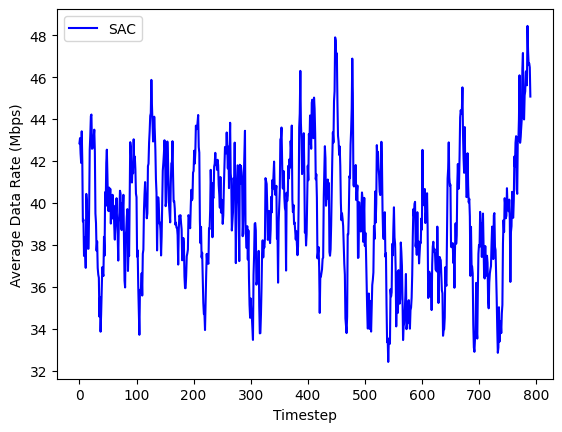

-------------
Average of total allocated power to each user (SAC):
-------------



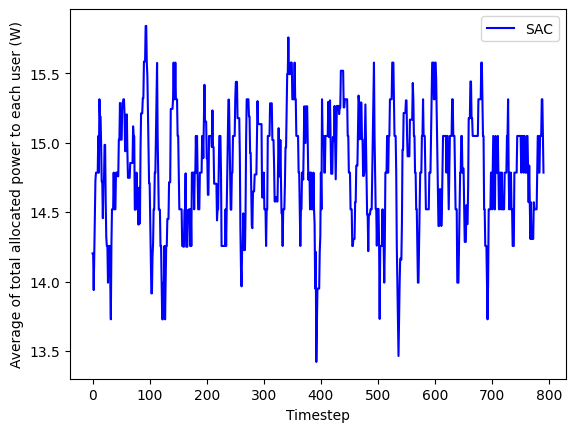

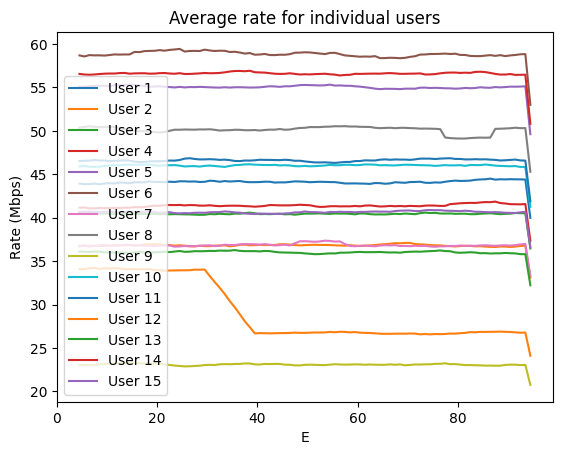

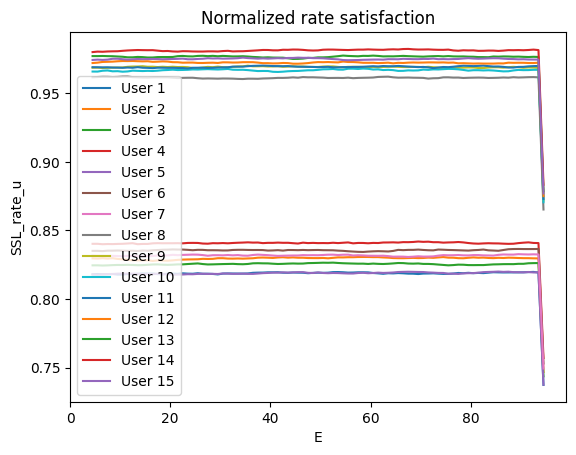

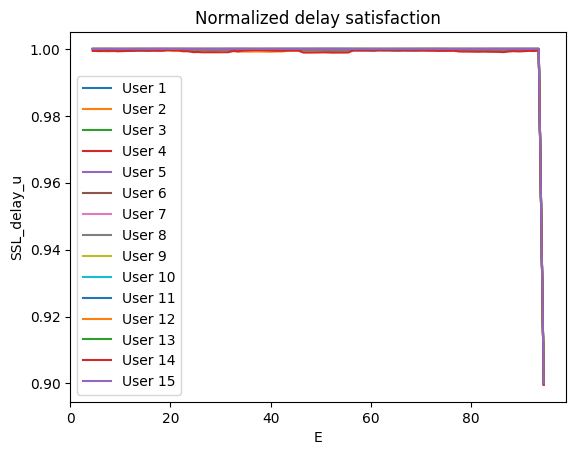

-------------
Sum of handovers :
-------------



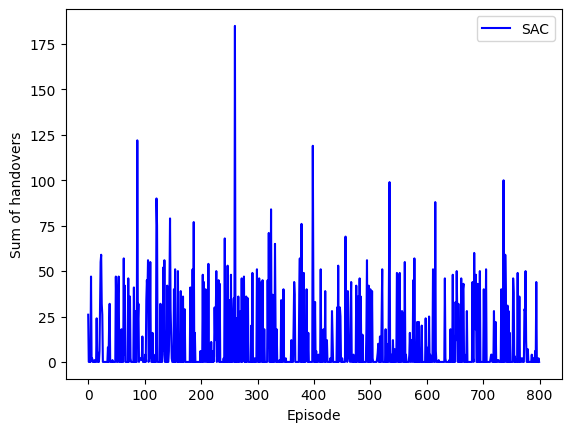

-------------
No. of satisfied delay and rate constraints (Max= 2*U):
-------------



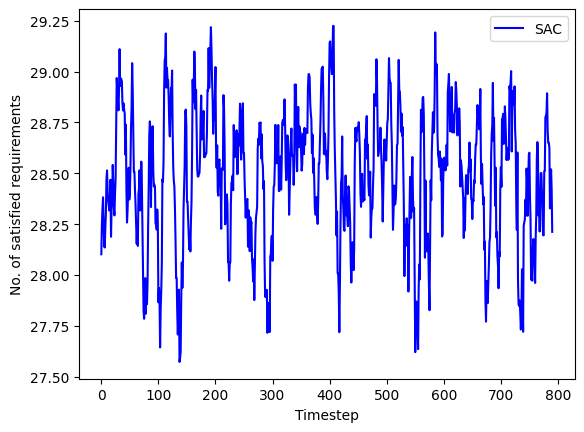

Total time for 100 timesteps (15 users) in 800 Episdoes (aka iterations or epochs): 6.0 hours 30.0 minutes 48.14821004867554 seconds


In [2]:

plot_graph("logarithmic rewards",
           [moving_average(np.average(logarithmic_reward, axis=1), window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Episode",
           "logarithmic rewards")
#e,t
plot_graph("Mean episodic rewards",
           [moving_average(np.average(mat_reward, axis=1), window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Episode",
           "Mean episodic rewards")

plot_graph("Constraint Satisfaction",
           [moving_average(np.average(mat_satisfied_prb_constraint, axis=1), window_size), 
            moving_average(np.average(mat_satisfied_power_constraint, axis=1), window_size),
            moving_average(np.average(mat_satisfied_delay_constraint, axis=1), window_size),
            moving_average(np.average(mat_satisfied_rate_constraint, axis=1), window_size)],
           ['PRB (SAC)',
            'Power (SAC)',
            'Delay (SAC)',
            'Rate (SAC)'],
           ['red', 'blue', 'green', 'orange'],
           ['solid', 'solid', 'solid', 'solid'],
           "Episode",
           "Constraint Satisfaction Rate")

# %%%%%SSL%%%%%%
plot_graph("SSL Metrics",
           [moving_average(np.average(mat_ssl_rate, axis=0), window_size),
            moving_average(np.average(mat_ssl_delay, axis=0), window_size),
            moving_average(np.average(mat_ssl, axis=0), window_size)],
           ['Rate (SAC)',
            'Delay (SAC)',
            'SSL (SAC)'],
           ['blue', 'green', 'orange'],
           ['solid', 'solid', 'solid'],
           "Episode",
           "SSL Metrics")
# %%%%%Delay%%%%%%
# Calculate mean delay over users for SAC
mean_delay_sac = np.mean(np.mean(monte_mat_delay_tot, axis=1), axis=0)
# Plot the comparison graph
plot_graph("Comparison of Average E2E Delay (SAC)",
           [moving_average(mean_delay_sac , window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "Average E2E Delay (ms)")

#####################
mean_rate_sac = np.mean(np.mean(shannon, axis=1), axis=1)
# mean_rate_sac_smoothed = moving_average(mean_rate_sac, window_size)
plot_graph("Average Data Rate (SAC)",
           [moving_average(mean_rate_sac , window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "Average Data Rate (Mbps)")

#####################
mean_power_sac = np.mean(np.mean(mat_sum_power, axis=1), axis=1)
# mean_power_sac_smoothed = moving_average(mean_power_sac, window_size)
plot_graph("Average of total allocated power to each user (SAC)",
           [moving_average(mean_power_sac , window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "Average of total allocated power to each user (W)")

###
average_rate = np.mean(shannon, axis=1)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_rate[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('Rate (Mbps)')
plt.title('Average rate for individual users')
plt.legend()
plt.show()

###
average_rate_ssl_u = np.mean(mat_fittingness_u_rate, axis=0)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_rate_ssl_u[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('SSL_rate_u')
plt.title('Normalized rate satisfaction')
plt.legend()
plt.show()

###
average_delay_ssl_u = np.mean(mat_fittingness_u_delay, axis=1)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_delay_ssl_u[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('SSL_delay_u')
plt.title('Normalized delay satisfaction')
plt.legend()
plt.show()
###
plot_graph("Sum of handovers ",
           [moving_average(np.sum(mat_count_handovers, axis=1) , 1)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Episode",
           "Sum of handovers")

####
plot_graph("No. of satisfied delay and rate constraints (Max= 2*U)",
           [moving_average(np.average(mat_no_of_satisfied_delay_and_rate_constraint, axis=1), window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "No. of satisfied requirements")
###

print(style.UNDERLINE + "Total time for {} timesteps ({} users) in {} Episdoes (aka iterations or epochs): {}".format(T, USER_NO, E, convert_seconds(np.sum(mat_episode_runtime))))



-------------
Mean episodic rewards:
-------------



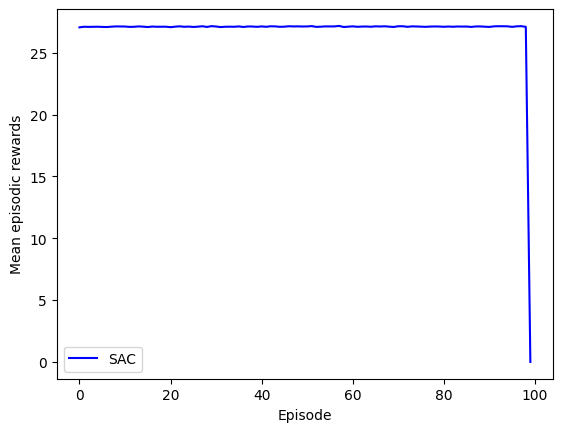

In [4]:
plot_graph("Mean episodic rewards",
           [moving_average(np.average(mat_reward, axis=0), 1)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Episode",
           "Mean episodic rewards")

In [ ]:
import numpy as np
plot_graph("SSL Metrics",
           [np.mean(mat_ssl_rate, axis=0),
            np.mean(mat_ssl_delay, axis=0),
            np.average(mat_ssl, axis=0)],
           ['Rate (SAC)',
            'Delay (SAC)',
            'SSL (SAC)'],
           ['blue', 'green', 'orange'],
           ['solid', 'solid', 'solid'],
           "Episode",
           "SSL Metrics")

In [ ]:
def __init__(self, alpha, beta, n_actions, input_dims, tau = 0.005,
            layer1_size = 500, layer2_size = 256, batch_size = 32, reward_scale = 2): #input_dims (state size)
        self.gamma = 0.99 
# config.yaml lstm
# config.yaml 
USER_NO: 15 #10 #20 # 4
BW: 180000  # %  180 kHz  (to be updated after consulting with Faouzi)
PRB_NO: 200 #  (to be updated after consulting with Faouzi)
SIGMA_NOISE: 10**(-17.4) #3.981e-18 # # = -174 dBm <tnsm23nouruzi> #
ETA_AREA: 3 # for rural areas according to TS 38.215 (Used in the Rayleigh/Distance formula for calculating data rate (Shannon)); equal to 3 for rural; 4 for urban areas # check also 38.913 for mobility scenarios and classes
X_LIM: 1000
Y_LIM: 1000
#CU_NO: 1 # only 1 CU is envisioned. It is co-located with the Near-RT RIC
DU_NO: 2 # all connected to the CU
RU_PER_DU_NO: 3 # Each DU has 4 RUs; Total number of RUs = 4*2 = 8
#BS_NO: 20 # should be equal to RU_PER_DU_NO*DU_NO # static for now; Location.bs_location() --- now it is bound to 4 BSs. Can be changed later
FH_BW_CAPACITY: 5000 # 100 Mbps in twc23kavehmadani# Mbps (5 Gbps) (link between RU and its DU) #
E2_BW_CAPACITY: 100000 # 5 Gbps in twc23kavehmadani #Mbps (100 Gbps) (link between DU and Near-RT RIC (equal to F1, which is between DU and CU))
#VM_NO: 9 # 6
#VNF_NO: 5 # 5
#NODE_NO: 12
SLICE_NO: 3 #5 # number of slice types ; will be indexed from 0 to (SLICE_NO - 1)
MAX_POWER: 40 # in watts ; equals to 46 dBm <tvt23choi> # 12 # (to be updated after consulting with Faouzi) # 46 dBm in tvt23choi = 40 watts (Much higher than normal papers)
OMEGA_1: 0.3 # to use in SSL weighting (for data rate term)
VELOCITY: 0 #0 #-1 means random #35 # m/s [5,20,35,50] #             = self.V ##################################################
CONST_D_MAX: -1 # 20 #-1 # ms
CONST_R_MIN: -1 # 5 #-1 # Mbps  
#ISOLATION_ORDER: -1
PACKET_SIZE: -1 # 0.012 # based on 1500 bytes for eMBB # in mbits # -1 # twc23kavehmadani: 1 KB for URLLC and 125 KB for eMBB
#PACKET_NO: 830  # 500 # -1 # packet generation rate per second # 0.012*500 = 6 Mbps # 0.012*830 = 9.96 Mbps
RAYLEIGH_SCALE: 1 # sigma in Rayleigh formula
#Episodes (T) and Number of monte-carlo runs:#
E: 10 #1000# episodes/epochs for learning (the loop before T loop (replaces MC loop))
T: 1000 #100# 14000 # 1000  # Number of timeslots
#MC: 3  # Number of Monte-carlo runs
#Hyperparameters for the DRL algorithm
ALPHA_ACT: 0.00001 #01 # 0.00001 # 0.00001 #0.000001 # actor's learning rate
BETA_ACT: 0.00005 # 0.00005 # 0.00005 # 0.00005 # 0.000005 # Critic's learning rate
VAR: 1
DECAY_VAR: 0.999 #95 #95 # .995 # can determine the ratio of exploration to exploitation
PSI: 0.5 # for putting two last actions in states
XI: 5 # shaping parameter for SSL^B_u and SSL^D_u
IOTA: 0.1 # regularization parameter that controls the penalty for low satisfaction levels

In [ ]:
plot_graph("SSL Metrics",
           [np.average(mat_ssl_rate, axis=0),
            np.average(mat_ssl_delay, axis=0),
            np.average(mat_ssl, axis=0)],
           ['Rate (SAC)',
            'Delay (SAC)',
            'SSL (SAC)'],
           ['blue', 'green', 'orange'],
           ['solid', 'solid', 'solid'],
           "Episode",
           "SSL Metrics")